# ***Task 1: Build the Data Collection Pipeline***

In [ ]:
# Importing Libraries
import pandas as pd
import requests
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
# Collect API Data
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    items = data.get("items", [])
else:
    items = []

In [ ]:
# Create the DataFrame
df = pd.DataFrame(items)

# Select required columns
required_columns = [
    'name', 'owner', 'language', 'stargazers_count',
    'forks_count', 'watchers_count', 'open_issues_count',
    'created_at', 'updated_at', 'license'
]
df = df[required_columns]

print("DataFrame Shape after selecting columns:", df.shape)
df.head(3)

DataFrame Shape after selecting columns: (100, 10)


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,198092,76225,198092,2989,2015-11-07T01:19:20Z,2026-08-31T16:33:56Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164665,34407,164665,2406,2018-10-29T13:56:00Z,2026-08-31T15:40:45Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89971,22131,89971,13,2021-03-03T01:34:05Z,2026-08-31T16:25:28Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."


In [ ]:
# Extract nested values for owner and license
df['owner'] = df['owner'].apply(lambda x: x.get('login') if isinstance(x, dict) else None)
df['license'] = df['license'].apply(lambda x: x.get('name') if isinstance(x, dict) else None)

# Handle missing values
df['language'] = df['language'].fillna('Unknown')
df['license'] = df['license'].fillna('No License')

# Handle duplicate records
df = df.drop_duplicates()

print("DataFrame Shape after cleaning:", df.shape)

DataFrame Shape after cleaning: (100, 10)


In [ ]:
# Convert date columns to appropriate datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

# Rename columns for clarity and consistency in SQL
rename_mapping = {
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
}
df = df.rename(columns=rename_mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [ ]:
# Save the Dataset
output_file = 'github_projects.csv'
df.to_csv(output_file, index=False)
print(f"Dataset successfully saved to {output_file}")

# Verify the saved dataset
verified_df = pd.read_csv(output_file)
print("Verified DataFrame Shape:", verified_df.shape)
verified_df.head()

Dataset successfully saved to github_projects.csv
Verified DataFrame Shape: (100, 10)


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,198092,76225,198092,2989,2015-11-07 01:19:20+00:00,2026-08-31 16:33:56+00:00,Apache License 2.0
1,transformers,huggingface,Python,164665,34407,164665,2406,2018-10-29 13:56:00+00:00,2026-08-31 15:40:45+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89971,22131,89971,13,2021-03-03 01:34:05+00:00,2026-08-31 16:25:28+00:00,MIT License
3,funNLP,fighting41love,Python,82797,15277,82797,52,2018-08-21 11:20:39+00:00,2026-08-31 15:18:48+00:00,No License
4,awesome-machine-learning,josephmisiti,Python,74226,15637,74226,30,2014-07-15 19:11:19+00:00,2026-08-31 13:39:34+00:00,Other


# ***Task 2: Store & Analyse the Data***

In [ ]:
# 1. Read the CSV file saved from the previous step
df = pd.read_csv('github_projects.csv')

# 2. Connect to SQLite database (creates a new database file named github.db)
conn = sqlite3.connect('github.db')

# 3. Import the DataFrame into a table named Repositories
df.to_sql('Repositories', conn, if_exists='replace', index=False)

print("Database created and data imported successfully into 'Repositories' table!")

Database created and data imported successfully into 'Repositories' table!


In [ ]:
# Filtering & Searching Queries
query_stars = "SELECT name, stars FROM Repositories WHERE stars > 10000"
df_stars = pd.read_sql(query_stars, conn)
display(df_stars.head())

query_name = "SELECT name FROM Repositories WHERE name LIKE '%Machine%'"
df_name = pd.read_sql(query_name, conn)
display(df_name.head())

,name,stars
0,tensorflow,198092
1,transformers,164665
2,ML-For-Beginners,89971
3,funNLP,82797
4,awesome-machine-learning,74226


,name
0,awesome-machine-learning
1,500-AI-Machine-learning-Deep-learning-Computer...
2,machine-learning-for-software-engineers
3,homemade-machine-learning
4,awesome-production-machine-learning


In [ ]:
# Logical Operators
query_logical_1 = """
SELECT name, language, stars
FROM Repositories
WHERE language != 'Unknown' AND stars > 5000
"""
display(pd.read_sql(query_logical_1, conn).head())

query_logical_2 = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 20000 OR forks > 5000
"""
display(pd.read_sql(query_logical_2, conn).head())

,name,language,stars
0,tensorflow,C++,198092
1,transformers,Python,164665
2,ML-For-Beginners,Jupyter Notebook,89971
3,funNLP,Python,82797
4,awesome-machine-learning,Python,74226


,name,stars,forks
0,tensorflow,198092,76225
1,transformers,164665,34407
2,ML-For-Beginners,89971,22131
3,funNLP,82797,15277
4,awesome-machine-learning,74226,15637


In [ ]:
# Sorting & Limiting Queries - Top 10
query_top10 = """
SELECT name, owner, stars, language
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""
top_10_df = pd.read_sql(query_top10, conn)
display(top_10_df)

,name,owner,stars,language
0,tensorflow,tensorflow,198092,C++
1,transformers,huggingface,164665,Python
2,ML-For-Beginners,microsoft,89971,Jupyter Notebook
3,funNLP,fighting41love,82797,Python
4,awesome-machine-learning,josephmisiti,74226,Python
5,scikit-learn,scikit-learn,67112,Python
6,gradio,gradio-app,43441,Python
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36659,Unknown
8,C-Plus-Plus,TheAlgorithms,34623,C++
9,netron,lutzroeder,33432,JavaScript


In [ ]:
# Aggregate Functions
query_agg = """
SELECT
    COUNT(*) AS total_repositories,
    AVG(stars) AS average_stars
FROM Repositories
"""
agg_df = pd.read_sql(query_agg, conn)
display(agg_df)

,total_repositories,average_stars
0,100,20862.19


In [ ]:
# Grouping Analysis
query_group = """
SELECT
    language,
    COUNT(*) AS repo_count
FROM Repositories
GROUP BY language
HAVING repo_count > 5
ORDER BY repo_count DESC
"""
group_df = pd.read_sql(query_group, conn)
display(group_df)

,language,repo_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


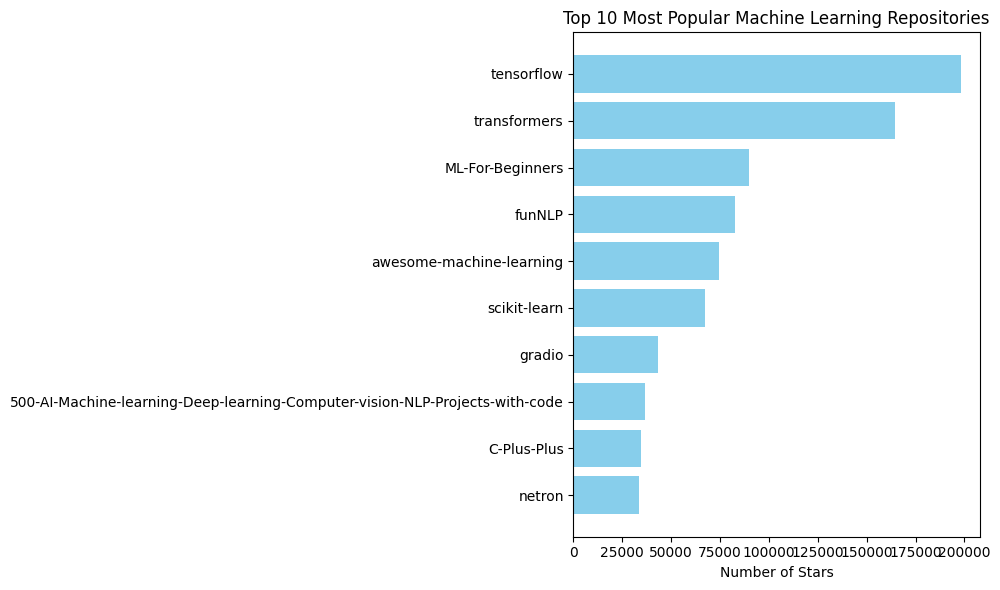

In [ ]:
# Bar chart for Top 10 repositories by stars
plt.figure(figsize=(10, 6))
plt.barh(top_10_df['name'][::-1], top_10_df['stars'][::-1], color='skyblue')
plt.xlabel('Number of Stars')
plt.title('Top 10 Most Popular Machine Learning Repositories')
plt.tight_layout()
plt.show()

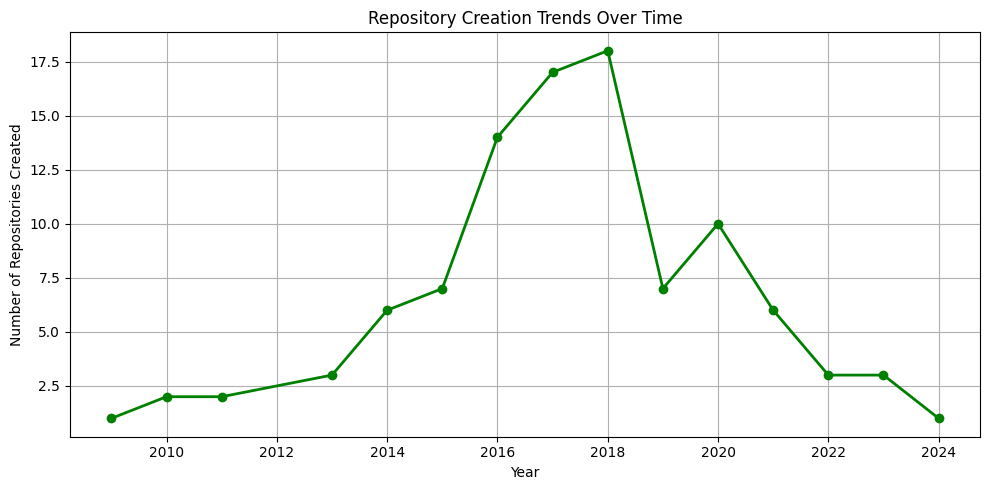

In [ ]:
# Line chart for repository creation trends over time
df['created_date'] = pd.to_datetime(df['created_date'])
df['year'] = df['created_date'].dt.year
yearly_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='line', marker='o', color='green', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Repositories Created')
plt.title('Repository Creation Trends Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

##Interpret Results & Final Insights

After executing the SQL queries and generating the visualizations, we can draw the following key conclusions from the data:

* **Top Repositories & Popularity:**
  * Foundational frameworks such as `tensorflow` and `transformers` lead the rankings with the highest number of stars, showing massive community support and widespread industry adoption.

* **Programming Language Dominance:**
  * Python is undeniably the primary language for machine learning development, backed by a wide margin in repository counts compared to other languages like C++.

* **Growth Trends Over Time:**
  * The timeline chart indicates a significant upward trend in repository creation, reflecting the rapid global expansion and growing interest in Artificial Intelligence over recent years.

# ***Task 3: Manage the Project Using Git and GitHub***

In [ ]:
from google.colab import files

# Download the CSV file
files.download('github_projects.csv')

# Download database file
files.download('github.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ethics Reflection

### Question 1: Why is it important to verify data collected from public APIs?
It is crucial to verify data from public APIs to ensure its accuracy, completeness, and reliability. Public datasets can contain missing values, formatting inconsistencies, or outdated information that could lead to flawed analysis or incorrect conclusions if left unchecked.

### Question 2: Why should data analysts document the source of their data?
Documenting data sources ensures transparency, reproducibility, and accountability. It allows other analysts or stakeholders to trace the origin of the data, verify its credibility, and reproduce the analysis or build upon it correctly.

### Question 3: How can missing or inaccurate data affect data analysis and decision-making?
Missing or inaccurate data can introduce significant bias, distort statistical metrics (such as means or totals), and lead to misleading insights. Relying on such data can result in poor, ungrounded decision-making and strategic errors in machine learning models or business applications.